# From Benchmark Accuracy to Operational Trust
### Evaluating ML-Based Intrusion Detection for Cybersecurity Decision Support

Sylvester Koh | ZZBU6601 Capstone Project

---

**Notebook scope.** This notebook implements the operational-readiness evaluation: it loads the UNSW-NB15 benchmark partitions, examines them, combines and re-splits them under controlled conditions, trains and compares intrusion-detection models, and evaluates them through operational metrics rather than benchmark accuracy alone.

**On code provenance.** Standard library call patterns (loading, splitting, preprocessing, evaluation) follow the official pandas and scikit-learn documentation and are marked as such. The project-specific decisions — target definition, leakage controls, the stratified re-split, metric selection and operational interpretation — were developed for this project.

## 1. Setup and imports

Library versions are recorded for reproducibility. Imports follow the scikit-learn API documentation; nothing project-specific happens here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# Fixed seed so every split and model run is reproducible (defensibility + repeatability).
RANDOM_STATE = 42

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('sklearn', sklearn.__version__)

pandas 3.0.2
numpy 2.4.4
sklearn 1.8.0


## 2. Load the provided partitions

UNSW-NB15 ships as two pre-built partitions: a training set and a testing set. They are loaded separately here so their properties can be examined *before* any modelling decision is made — rather than trusting the provided split.

*Reference: `pandas.read_csv` — pandas documentation.*

In [2]:
# Adjust paths if the CSVs sit elsewhere.
train_path = 'UNSW_NB15_training-set.csv'
test_path  = 'UNSW_NB15_testing-set.csv'

train_raw = pd.read_csv(train_path)
test_raw  = pd.read_csv(test_path)

print('training partition:', train_raw.shape)
print('testing  partition:', test_raw.shape)
train_raw.head()

training partition: (175341, 45)
testing  partition: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


## 3. Examine the provided partitions

This is the first methodological step, not a formality. The project's argument is that benchmark evaluation conditions cannot be taken at face value, so the provided split is examined for whether the two partitions share the same class distribution. If they differ, inheriting the split would confound model performance with a distribution difference between train and test — a small instance of the transfer problem the project studies.

### 3.1 Binary target balance in each partition

In [3]:
for name, df in [('TRAIN', train_raw), ('TEST', test_raw)]:
    attack = df['label'].mean() * 100
    print(f'{name}: attack(1) {attack:5.2f}%  |  normal(0) {100-attack:5.2f}%')

TRAIN: attack(1) 68.06%  |  normal(0) 31.94%
TEST: attack(1) 55.06%  |  normal(0) 44.94%


### 3.2 Attack-category distribution in each partition

The binary balance hides the detail that matters operationally. The attack categories are examined because the project's headline analysis breaks performance down by attack type. Note in particular the rare classes (Shellcode, Worms): their counts are an artefact of how the dataset's authors generated synthetic traffic, not a measure of real-world prevalence.

In [4]:
cat_tr = train_raw['attack_cat'].value_counts()
cat_te = test_raw['attack_cat'].value_counts()

compare = pd.DataFrame({
    'train_n': cat_tr,
    'train_pct': (cat_tr / len(train_raw) * 100).round(2),
    'test_n': cat_te,
    'test_pct': (cat_te / len(test_raw) * 100).round(2),
}).fillna(0)
compare['pct_diff'] = (compare['test_pct'] - compare['train_pct']).round(2)
compare = compare.sort_values('train_n', ascending=False)
compare

,train_n,train_pct,test_n,test_pct,pct_diff
attack_cat,,,,,
Normal,56000,31.94,37000,44.94,13.00
Generic,40000,22.81,18871,22.92,0.11
Exploits,33393,19.04,11132,13.52,-5.52
Fuzzers,18184,10.37,6062,7.36,-3.01
DoS,12264,6.99,4089,4.97,-2.02
Reconnaissance,10491,5.98,3496,4.25,-1.73
Analysis,2000,1.14,677,0.82,-0.32
Backdoor,1746,1.00,583,0.71,-0.29
Shellcode,1133,0.65,378,0.46,-0.19


### 3.3 Total supply of each class across both files

Because the rare classes are so scarce, it is worth knowing the *total* number of examples available across both partitions combined. This is the entire pool any model can learn the rare classes from — a number the operational-readiness discussion returns to.

In [5]:
combined_counts = (train_raw['attack_cat'].value_counts()
                   .add(test_raw['attack_cat'].value_counts(), fill_value=0)
                   .astype(int)
                   .sort_values(ascending=False))
total = int(combined_counts.sum())
supply = pd.DataFrame({
    'count': combined_counts,
    'pct_of_dataset': (combined_counts / total * 100).round(3),
})
print('Total examples per class (train + test), with proportion of full dataset:')
supply

Total examples per class (train + test), with proportion of full dataset:


,count,pct_of_dataset
attack_cat,,
Normal,93000,36.092
Generic,58871,22.847
Exploits,44525,17.280
Fuzzers,24246,9.410
DoS,16353,6.346
Reconnaissance,13987,5.428
Analysis,2677,1.039
Backdoor,2329,0.904
Shellcode,1511,0.586


### 3.4 Finding

The breakdown by attack category shows the distribution more clearly than the binary split. By rarity, the attack records form three clusters and an outlier:

- Common: Generic, Exploits, Fuzzers
- Medium: DoS, Reconnaissance
- Rare: Analysis, Backdoor, Shellcode
- Very rare (outlier): Worms, disproportionately few

These proportions are not a measure of how often each attack occurs in the real world, they reflect how the dataset's authors generated synthetic traffic for benchmarking. A security manager may not realise the model they are deploying is trained on this composition. It would be reasonable to expect normal traffic to form the majority of both partitions, yet the composition shows the inverse, attacks dominate. A model trained on this data may not reflect real network conditions, and the manager is effectively trusting an operational decision to the authors' judgement.

## 4. Combine the partitions

Having examined the two partitions and found that their class distributions differ (section 3), they are now stacked into a single dataset. Combining only happens *after* the examination, so the difference between the partitions has already been recorded as evidence rather than averaged away.

*Reference: `pandas.concat` — pandas documentation.*

In [6]:
combined = pd.concat([train_raw, test_raw], axis=0, ignore_index=True)
print('combined shape:', combined.shape)
print('combined label balance: attack(1) {:.2f}%'.format(combined['label'].mean()*100))
print('combined attack_cat totals:')
print(combined['attack_cat'].value_counts().to_string())

combined shape: (257673, 45)
combined label balance: attack(1) 63.91%
combined attack_cat totals:
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174


## 5. Stratified re-split (70/30)

The combined data is re-split into new training and test sets under controlled conditions. Two project decisions are encoded here:

- **70/30 ratio** — a conventional split that leaves enough test data to report rare-class recall with reasonable stability.
- **Stratify on `attack_cat`** (the 10-class label, not the binary `label`) — so every category, including the rarest, is split in the same proportion on both sides. Stratifying on the finest-grained label protects the rare-class test counts that the headline analysis depends on. Were the split stratified on the binary label only, the rare attack types could land disproportionately on one side by chance.

The split removes the train-to-test distribution difference found in section 3: both sides now carry the same class proportions, so later model comparisons reflect model differences rather than a distribution shift between train and test.

*Reference: `sklearn.model_selection.train_test_split` (with `stratify=`) — scikit-learn documentation.*

In [7]:
from sklearn.model_selection import train_test_split

# Keep three columns out of the features:
# label is the target we predict.
# attack_cat is kept aside for the per-type breakdown later, it is not an input.
# id is just a row number from the dataset, so it is not an input either.
y = combined['label']
strat_key = combined['attack_cat']   # stratify on the attack category, the finest label

train_df, test_df = train_test_split(
    combined,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=strat_key,
)

print('train set:', train_df.shape)
print('test set:', test_df.shape)
print('train label balance: attack(1) {:.2f}%'.format(train_df['label'].mean()*100))
print('test label balance: attack(1) {:.2f}%'.format(test_df['label'].mean()*100))


train set: (180371, 45)
test set: (77302, 45)
train label balance: attack(1) 63.91%
test label balance: attack(1) 63.91%


### 5.1 Verify the split preserved class proportions

Re-splitting lets the model be evaluated on a like-for-like basis, comparing apples with apples. The class distribution is held consistent between the train and test sets, so the model's performance can be read without a difference in class balance distorting the result.

The verification below counts each attack category in the train and test sets, converts each count to a percentage of its set, and places them side by side so the proportions can be compared directly. If `train_pct` and `test_pct` match for every category, the split preserved the class distribution. The categories are ordered from most to least common to clearly present the rarity.

In [8]:
n_tr, n_te = len(train_df), len(test_df)
verify = pd.DataFrame({
    'train_n': train_df['attack_cat'].value_counts(),
    'train_pct': (train_df['attack_cat'].value_counts() / n_tr * 100).round(3),
    'test_n': test_df['attack_cat'].value_counts(),
    'test_pct': (test_df['attack_cat'].value_counts() / n_te * 100).round(3),
}).fillna(0)
verify['train_n'] = verify['train_n'].astype(int)
verify['test_n']  = verify['test_n'].astype(int)
verify = verify.sort_values('train_n', ascending=False)
verify

,train_n,train_pct,test_n,test_pct
attack_cat,,,,
Normal,65100,36.092,27900,36.092
Generic,41210,22.847,17661,22.847
Exploits,31167,17.279,13358,17.280
Fuzzers,16972,9.409,7274,9.410
DoS,11447,6.346,4906,6.347
Reconnaissance,9791,5.428,4196,5.428
Analysis,1874,1.039,803,1.039
Backdoor,1630,0.904,699,0.904
Shellcode,1058,0.587,453,0.586


### 5.2 Note on rare-class test counts

The verify dataframe confirms that re-splitting preserved the proportions of the attack categories. Even so, the Worms category remains an outlier with very few test cases: 52 records form the entire basis for evaluating how the model handles worm attacks. So few cases introduce instability (one misclassification moves recall by two whole percentage points), which erodes confidence in any rare-class figure, in either direction. Breaking down the figure by attack category exposes an assumption a security manager would need to defend: that a model trained on this benchmark can give a trustworthy read on rare but dangerous attacks, when the data to verify that barely exists.

## 6. Preprocessing

Preprocessing encodes two project decisions: the leakage controls, and the encoding/scaling strategy. All transforms are fitted on the **training set only** and then applied to the test set, so no test information influences how the data is prepared.

*References: `sklearn.compose.ColumnTransformer`, `sklearn.preprocessing.OneHotEncoder`, `sklearn.preprocessing.StandardScaler`, `sklearn.pipeline.Pipeline` — scikit-learn documentation.*

### 6.1 Separate features from target, and remove leakage columns

Three columns are kept out of the feature set, each for a specific reason:

- **`label`** is the prediction *target*, not an input. It is held aside as `y`.
- **`attack_cat`** is removed from the features because it encodes the answer: every non-`Normal` value corresponds to `label = 1`. Leaving it in would let a model read the target directly. It is retained in a separate variable for the later per-attack-type breakdown, not used as an input.
- **`id`** is a row index created when the dataset was assembled. It carries no information about network behaviour and would let a model memorise the dataset's construction order. It is dropped.

_(The raw-capture version of UNSW-NB15 also contains source/destination IP and port columns. Those are absent from this partition; their exclusion is discussed as a limitation in the report rather than handled here.)_

In [9]:
TARGET = 'label'
LEAK_COLS = ['id', 'attack_cat']   # removed from features (id: artefact; attack_cat: leaks target)

# Targets / auxiliary labels held aside
y_train = train_df[TARGET].reset_index(drop=True)
y_test  = test_df[TARGET].reset_index(drop=True)
# attack_cat kept ONLY for the per-type breakdown in a later section
cat_train = train_df['attack_cat'].reset_index(drop=True)
cat_test  = test_df['attack_cat'].reset_index(drop=True)

# Feature matrices: drop target + leakage columns
X_train = train_df.drop(columns=[TARGET] + LEAK_COLS).reset_index(drop=True)
X_test  = test_df.drop(columns=[TARGET] + LEAK_COLS).reset_index(drop=True)

print('feature columns:', X_train.shape[1])
print('train features:', X_train.shape, '| test features:', X_test.shape)
assert 'attack_cat' not in X_train.columns and 'id' not in X_train.columns, 'leakage column present!'
print('leakage check passed: id and attack_cat are not in the feature set')

feature columns: 42
train features: (180371, 42) | test features: (77302, 42)
leakage check passed: id and attack_cat are not in the feature set


### 6.2 Identify categorical and numeric columns

The three categorical columns (`proto`, `service`, `state`) are separated from the numeric columns so each group can be transformed appropriately. `proto` has many distinct values; the baseline approach one-hot encodes all of them, with grouping of rare protocols noted as a refinement in the report.

In [10]:
categorical_cols = ['proto', 'service', 'state']
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

print('categorical ({}):'.format(len(categorical_cols)), categorical_cols)
print('numeric ({}):'.format(len(numeric_cols)))
for c in categorical_cols:
    print(f'  {c}: {X_train[c].nunique()} categories in train')

categorical (3): ['proto', 'service', 'state']
numeric (39):
  proto: 133 categories in train
  service: 13 categories in train
  state: 9 categories in train


### 6.3 Build the shared preprocessing transformer

A single `ColumnTransformer` is used for every model, so all four models receive an identical input matrix — the cleanest basis for a fair comparison. Numeric columns are standardised; categorical columns are one-hot encoded. `handle_unknown='ignore'` ensures any category seen in test but not in train (possible after the re-split) does not break the transform. Scaling is required by Logistic Regression and is simply ignored by the tree models, which split on value order and are unaffected by scale.

The transformer is defined here but **not yet fitted** — it is fitted inside each model's pipeline on the training data only, in the next section.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='drop',
)
print('ColumnTransformer defined (not yet fitted).')
print('Will be fitted on training data only, inside each model pipeline.')

ColumnTransformer defined (not yet fitted).
Will be fitted on training data only, inside each model pipeline.


### 6.4 Note on leakage controls

Scaling and encoding must only be fitted on the training set for a fair test. The scaler's mean and standard deviation should be learned from training data only; fitting on the combined set computes them partly from the test set, so test statistics leak into how the training data is transformed. This produces deceptively better performance metrics that an audit would likely expose.

## 7. Model training: baseline and class-weighted

Four classifiers are compared. Each is trained twice:

- **Unweighted (baseline)** — the model optimises on the data as-is. This exposes how the model behaves when nothing corrects for the cost of different errors.
- **Class-weighted (operational response)** — errors on the minority class are penalised more heavily, reflecting the operational reality that a missed attack is more costly than a false alert. The distance between the baseline and the weighted result is the readiness gap this project measures.

Each model sits inside the shared preprocessing pipeline, so all four receive identical input and the comparison is fair. A fixed `random_state` makes every run reproducible.

*References: `sklearn.linear_model.LogisticRegression`, `sklearn.tree.DecisionTreeClassifier`, `sklearn.ensemble.RandomForestClassifier`, `sklearn.ensemble.HistGradientBoostingClassifier`, `sklearn.pipeline.Pipeline` — scikit-learn documentation.*

### 7.1 Define the models

Three models accept scikit-learn's `class_weight='balanced'` directly. `HistGradientBoostingClassifier` does not take `class_weight`; the equivalent effect is achieved by passing `sample_weight` at fit time, computed from class frequencies. The intent is identical — penalise minority-class errors more — only the API differs, and this is noted so the difference in the code is explainable.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# The four baseline models (no class weighting).
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

# The same four models with class weighting turned on.
# HistGradientBoosting has no class_weight option, so it is left plain here
# and given sample weights later when it is trained.
weighted_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

print('Models defined.')


Models defined.


### 7.2 Train all models, both conditions

Each model is fitted inside the shared pipeline. Fitted pipelines and their test predictions are stored so the evaluation sections can run without retraining. Training time is recorded — a practical feasibility consideration for the workflow.

In [13]:
import time

# Dictionaries to store results. The key is (model name, condition),
# for example ('Random Forest', 'baseline').
trained = {}   # the fitted pipeline for each model
preds = {}     # the predicted labels on the test set
proba = {}     # the predicted probability of attack, used later for PR-AUC

# Train every model in both conditions.
for condition in ['baseline', 'weighted']:
    if condition == 'baseline':
        model_set = baseline_models
    else:
        model_set = weighted_models

    for name in model_set:
        model = model_set[name]
        pipe = Pipeline([('prep', preprocess), ('clf', model)])

        start = time.time()
        # HistGradientBoosting cannot take class_weight, so when we want the
        # weighted version we pass sample weights to its fit step instead.
        if condition == 'weighted' and name == 'HistGradientBoosting':
            weights = compute_sample_weight(class_weight='balanced', y=y_train)
            pipe.fit(X_train, y_train, clf__sample_weight=weights)
        else:
            pipe.fit(X_train, y_train)
        run_time = time.time() - start

        trained[(name, condition)] = pipe
        preds[(name, condition)] = pipe.predict(X_test)
        # column 1 is the probability of the attack class (label = 1)
        proba[(name, condition)] = pipe.predict_proba(X_test)[:, 1]

        print(condition, '|', name, '| trained in', round(run_time, 1), 's')

print('Done. 4 models x 2 conditions = 8 fits.')


baseline | Logistic Regression | trained in 12.6 s


baseline | Decision Tree | trained in 5.4 s


baseline | Random Forest | trained in 28.5 s


baseline | HistGradientBoosting | trained in 21.3 s


weighted | Logistic Regression | trained in 8.3 s


weighted | Decision Tree | trained in 5.0 s


weighted | Random Forest | trained in 28.8 s


weighted | HistGradientBoosting | trained in 21.2 s
Done. 4 models x 2 conditions = 8 fits.


## 8. Binary metrics comparison

Each model is scored on the binary task (attack vs normal) under both conditions. The metrics are chosen for what they reveal operationally:

- **Recall** — of all real attacks, how many were caught. A miss is a false negative: an undetected attack, the costly error.
- **Precision** — of all attack alerts raised, how many were genuine. False positives drive analyst alert fatigue.
- **F1** — a single balance of recall and precision; reported, but not led on, because it can hide the trade-off between the two.
- **PR-AUC** — performance on the attack class across all decision thresholds. Chosen over ROC-AUC because ROC-AUC is inflated by the abundant, easily-classified normal traffic, whereas PR-AUC reflects performance on the class that matters.
- **Accuracy** — reported last and deliberately, to show it offers little discrimination here: every model looks strong on accuracy, which is the reassurance the project warns against.

*References: `sklearn.metrics.recall_score`, `precision_score`, `f1_score`, `average_precision_score`, `accuracy_score` — scikit-learn documentation.*

In [14]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             accuracy_score, average_precision_score)

rows = []
for (name, cond), pred in preds.items():
    pr = proba[(name, cond)]
    rows.append({
        'model': name, 'condition': cond,
        'recall': recall_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'PR_AUC': average_precision_score(y_test, pr),
        'accuracy': accuracy_score(y_test, pred),
    })

metrics = pd.DataFrame(rows)
# order models logically, baseline before weighted
order = ['Logistic Regression','Decision Tree','Random Forest','HistGradientBoosting']
metrics['model'] = pd.Categorical(metrics['model'], categories=order, ordered=True)
metrics = metrics.sort_values(['model','condition']).reset_index(drop=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
metrics

,model,condition,recall,precision,f1,PR_AUC,accuracy
0,Logistic Regression,baseline,0.9669,0.8897,0.9267,0.9859,0.9023
1,Logistic Regression,weighted,0.9134,0.9377,0.9254,0.9862,0.9059
2,Decision Tree,baseline,0.9475,0.9505,0.9490,0.9361,0.9349
3,Decision Tree,weighted,0.9491,0.9501,0.9496,0.9359,0.9356
4,Random Forest,baseline,0.9586,0.9626,0.9606,0.9950,0.9497
5,Random Forest,weighted,0.9584,0.9618,0.9601,0.9950,0.9491
6,HistGradientBoosting,baseline,0.9471,0.9637,0.9553,0.9949,0.9434
7,HistGradientBoosting,weighted,0.9246,0.9814,0.9521,0.9949,0.9406


### 8.1 Baseline vs weighted: the effect of class weighting on the binary task

This view pivots recall and precision so the change from baseline to weighted is visible per model. The expected operational benefit of weighting — higher attack recall — does **not** appear here. On this benchmark, attacks are the majority class, so `class_weight='balanced'` prioritises the *normal* minority, making models more reluctant to flag attacks. Recall falls and precision rises: the trade-off moves the wrong way for attack detection. This is not a failure of weighting but evidence that the binary framing misrepresents the operational problem, which motivates the per-attack-type breakdown in the next section.

In [15]:
pivot = metrics.pivot_table(index='model', columns='condition',
                            values=['recall','precision'], observed=True)
pivot

precision            recall         
condition             baseline weighted baseline weighted
model                                                    
Logistic Regression     0.8897   0.9377   0.9669   0.9134
Decision Tree           0.9505   0.9501   0.9475   0.9491
Random Forest           0.9626   0.9618   0.9586   0.9584
HistGradientBoosting    0.9637   0.9814   0.9471   0.9246

### 8.2 Reading of the binary results

All four measures of performance are consistently high. Figures above 90% promise assurance for a manager under pressure to deliver. However, examination of the mechanisms used to derive these metrics tells a different story. The dataset holds attacks in majority over normal traffic. This is inverted for a SOC, which would monitor normal traffic as the majority, and attacks as the exception.

Because normal traffic is the smaller class in this dataset, the weighting pushes the model to avoid mislabelling normal traffic as an attack. The side effect is that the model holds back from flagging genuine attacks.

This implicates the deployment to real operations: a missed attack has more severe consequence than a false alert. The manager would need to defend the weighted model's trade of recall for precision, when business owners would prefer it err toward catching attacks.

## 9. Confusion matrices

The confusion matrix shows the two error types directly: false negatives (real attacks missed) and false positives (normal traffic flagged). These are the operational errors from Part A — a false negative is an undetected attack; a false positive contributes to alert fatigue. Matrices are shown for the baseline models so the error balance can be compared across classifiers.

*Reference: `sklearn.metrics.confusion_matrix`, `ConfusionMatrixDisplay` — scikit-learn documentation.*

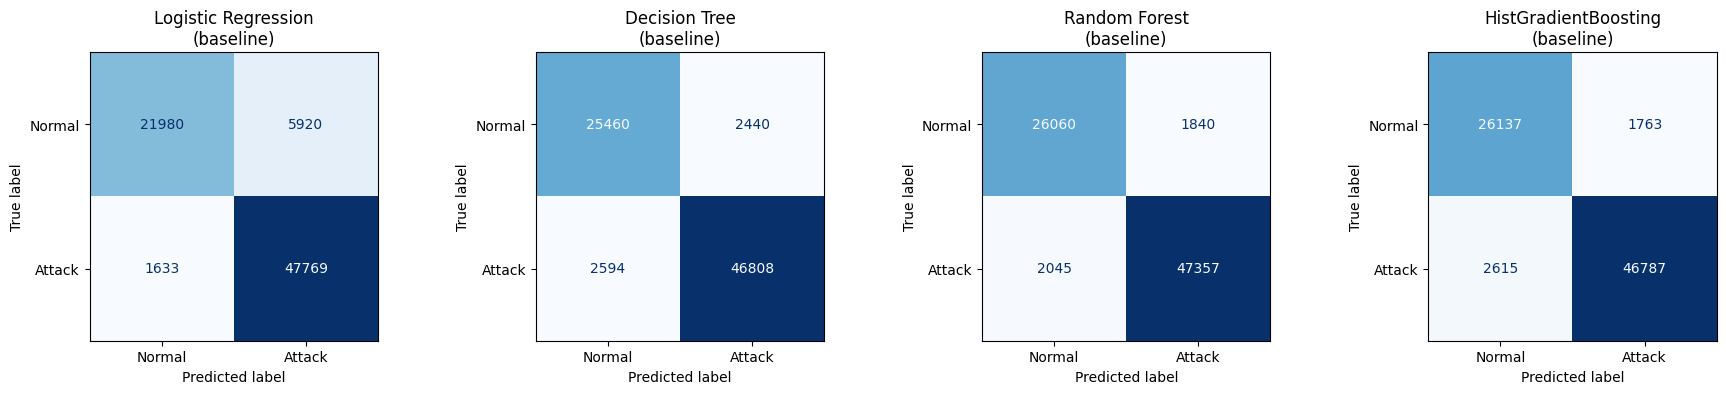

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models4 = ['Logistic Regression','Decision Tree','Random Forest','HistGradientBoosting']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, name in zip(axes, models4):
    cm = confusion_matrix(y_test, preds[(name, 'baseline')])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Attack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n(baseline)')
plt.tight_layout()
plt.show()

In [17]:
# Tabulate the error balance so the models can be compared directly,
# rather than read separately from four matrices.
from sklearn.metrics import confusion_matrix

rows = []
for name in models4:
    cm = confusion_matrix(y_test, preds[(name, 'baseline')])
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    rows.append({
        'model': name,
        'missed_attacks_FN': int(fn),
        'false_alerts_FP': int(fp),
        'FP_to_FN_ratio': round(fp/fn, 2),
    })
error_balance = pd.DataFrame(rows).set_index('model')
error_balance

,missed_attacks_FN,false_alerts_FP,FP_to_FN_ratio
model,,,
Logistic Regression,1633,5920,3.6300
Decision Tree,2594,2440,0.9400
Random Forest,2045,1840,0.9000
HistGradientBoosting,2615,1763,0.6700


### 9.1 Reading the error balance

The confusion matrix of each model surfaces another operational caveat behind the above-90% figure: the models handle errors differently. Logistic Regression over-flags alerts and HistGB under-flags. This follows from each model's boundary logic, tree models trace the line between normal and attack traffic more tightly, raising fewer false alerts, with Random Forest the most balanced of them. It is a distinction a manager procuring by the accuracy figure alone cannot see.

## 10. Per-attack-type breakdown (headline analysis)

The binary metrics give a single recall figure per model. This section disaggregates that figure by attack category: for each real attack type, what fraction did the model catch? This is where aggregate performance is tested against operational reality.

The detection rate per type is the recall computed only over the rows of that attack category — of all the real `Worms` in the test set, how many were flagged as attack, and so on. Normal traffic is excluded because the question is specifically about catching each kind of attack.

In [18]:
attack_order = ['Generic','Exploits','Fuzzers','DoS','Reconnaissance',
                'Analysis','Backdoor','Shellcode','Worms']
attack_cats = [c for c in attack_order if c in cat_test.unique()]

def per_type_recall(pred):
    # For each attack type, work out the fraction of those real attacks
    # that the model flagged as an attack (predicted label 1).
    result = {}
    for c in attack_cats:
        is_this_type = (cat_test == c).values
        n = int(is_this_type.sum())
        if n > 0:
            result[c] = (pred[is_this_type] == 1).mean()
        else:
            result[c] = float('nan')
    return result

# Build a table of per-type detection rate for the four baseline models.
breakdown = pd.DataFrame({name: per_type_recall(preds[(name,'baseline')]) for name in models4})
breakdown.insert(0, 'test_n', [int((cat_test==c).sum()) for c in attack_cats])

# Convert the detection rates to percentages for readability.
for name in models4:
    breakdown[name] = (breakdown[name] * 100).round(1)

print('Per-attack-type detection rate (%), baseline models:')
breakdown


Per-attack-type detection rate (%), baseline models:


,test_n,Logistic Regression,Decision Tree,Random Forest,HistGradientBoosting
Generic,17661,99.9000,99.9000,100.0000,100.0000
Exploits,13358,97.5000,97.9000,99.2000,98.8000
Fuzzers,7274,86.6000,71.2000,75.0000,68.4000
DoS,4906,98.0000,99.0000,99.7000,99.6000
Reconnaissance,4196,97.6000,99.2000,99.9000,99.8000
Analysis,803,91.2000,92.7000,90.9000,86.1000
Backdoor,699,96.6000,99.9000,100.0000,100.0000
Shellcode,453,95.4000,90.1000,97.1000,96.7000
Worms,52,96.2000,100.0000,100.0000,100.0000


### 10.1 Baseline vs weighted on the weak class

Class weighting was introduced to improve detection of under-served classes. This view compares baseline and weighted detection per attack type for the two strongest models. The effect is the opposite of the intended one: weighting does not recover the weakest class and in places reduces it further, because the benchmark's inverted class balance directs the weighting toward the normal class rather than toward attacks.

In [19]:
for name in ['Random Forest','HistGradientBoosting']:
    base = per_type_recall(preds[(name,'baseline')])
    wts  = per_type_recall(preds[(name,'weighted')])
    cmp = pd.DataFrame({
        'test_n': [int((cat_test==c).sum()) for c in attack_cats],
        'baseline_%': [round(base[c]*100,1) for c in attack_cats],
        'weighted_%': [round(wts[c]*100,1) for c in attack_cats],
    }, index=attack_cats)
    cmp['delta_%'] = (cmp['weighted_%'] - cmp['baseline_%']).round(1)
    print(f'\n{name}:')
    print(cmp.to_string())


Random Forest:
                test_n  baseline_%  weighted_%  delta_%
Generic          17661    100.0000    100.0000   0.0000
Exploits         13358     99.2000     99.1000  -0.1000
Fuzzers           7274     75.0000     74.8000  -0.2000
DoS               4906     99.7000     99.7000   0.0000
Reconnaissance    4196     99.9000     99.9000   0.0000
Analysis           803     90.9000     91.3000   0.4000
Backdoor           699    100.0000    100.0000   0.0000
Shellcode          453     97.1000     97.6000   0.5000
Worms               52    100.0000    100.0000   0.0000



HistGradientBoosting:
                test_n  baseline_%  weighted_%  delta_%
Generic          17661    100.0000    100.0000   0.0000
Exploits         13358     98.8000     98.2000  -0.6000
Fuzzers           7274     68.4000     55.2000 -13.2000
DoS               4906     99.6000     99.3000  -0.3000
Reconnaissance    4196     99.8000     99.5000  -0.3000
Analysis           803     86.1000     83.8000  -2.3000
Backdoor           699    100.0000     99.7000  -0.3000
Shellcode          453     96.7000     93.4000  -3.3000
Worms               52    100.0000    100.0000   0.0000


### 10.2 Visual: detection rate by attack type

A bar chart of per-type detection makes the variation visible at a glance — uniformly high for most categories, with the Fuzzers class standing out as the weak point despite being common.

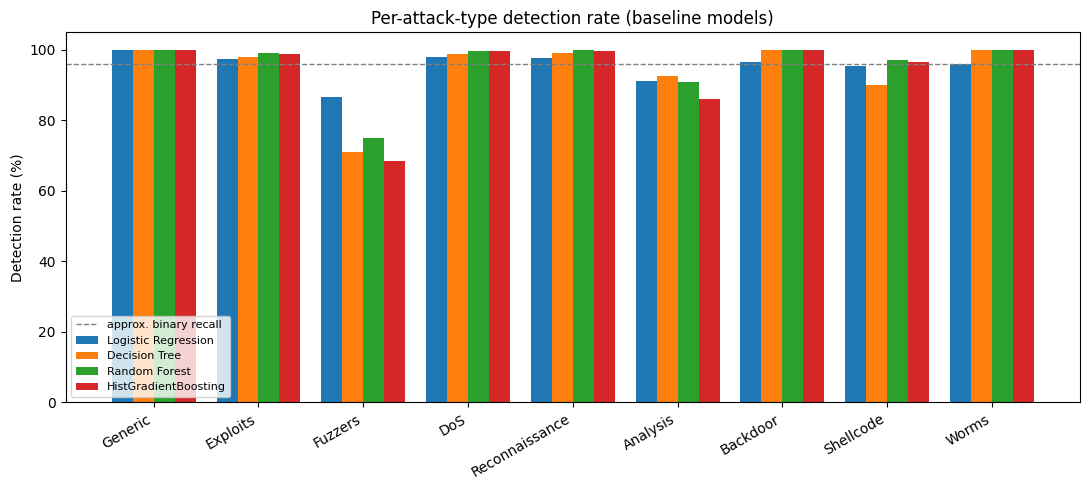

In [20]:
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(attack_cats))
w = 0.2
for i, name in enumerate(models4):
    vals = [per_type_recall(preds[(name,'baseline')])[c]*100 for c in attack_cats]
    ax.bar(x + i*w, vals, w, label=name)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(attack_cats, rotation=30, ha='right')
ax.set_ylabel('Detection rate (%)')
ax.set_title('Per-attack-type detection rate (baseline models)')
ax.axhline(96, ls='--', lw=1, color='grey', label='approx. binary recall')
ax.legend(fontsize=8)
ax.set_ylim(0,105)
plt.tight_layout()
plt.show()

### 10.3 Interpretation of the breakdown

It is one thing to accept a 96% recall figure, and another to break that 96% down by attack category to evaluate how the model detects specific attacks. It is surprising that Worms are caught despite few records, the attack's intention is to propagate, and this produces a distinctive signature the model learns even from few examples. It is equally surprising that Fuzzers are an outlier, detected 25 to 30 percentage points lower than other attacks. This shows a pattern of detection tracking how distinctive an attack appears, not how often it occurs.

A Fuzzer is designed to mimic normal traffic, making it the most deceptive category. This makes it the most diagnostic class for operational readiness: if the model can separate malicious traffic designed to mimic normal patterns, it can likely separate the less deceptive categories too.

Weighting is the standard first response to an underperforming class, but applied here it reduces Fuzzer detection (a 13-point drop for HistGB). The dataset's inverted balance, attacks being the majority, means the weighting protects the Normal class, causing the correction to pull the wrong way.

With such few test cases for Worms, a 100% catch rate cannot be claimed confidently.

A manager who'd accept the 96% would deploy a model that performs well on most attacks but is weakest on Fuzzers, the category designed to evade detection. This weakness surfaces only under closer inspection. A manager relying on the headline figure would carry it into deployment, unexamined. An audit would expose this gap, which is why this degree of inspection belongs as due diligence.